# Chart 2 Loss of control, wellbeing and daily playtime

**Message:** *The more players lose control, the more often they have low wellbeing, and the longer these players spend gaming each day.*

**Question:** how is losing control over gaming linked to players' wellbeing and to the time they spend playing?

**Data:** Open Play v1.2.6
- `survey_biweekly`: one row = one questionnaire (wellbeing, depression, loss of control);
- `xbox`, `nintendo`, `steam`: gaming sessions **measured by the consoles**.

## Step 1 Load the files

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = "https://github.com/digital-wellbeing/open-play/raw/v1.2.6/data/clean/"

# Biweekly survey: one row = one questionnaire
survey = pd.read_csv(base + "survey_biweekly.csv.gz", low_memory=False, parse_dates=["date"])

# Gaming sessions from the 3 consoles: who played, when, and for how long (minutes)
xbox = pd.read_csv(base + "xbox.csv.gz", usecols=["pid", "session_start", "duration"])
nintendo = pd.read_csv(base + "nintendo.csv.gz", usecols=["pid", "session_start", "duration"])
steam = pd.read_csv(base + "steam.csv.gz", usecols=["pid", "approximate_session_start", "minutes"])

print(survey.shape, xbox.shape, nintendo.shape, steam.shape)

(6844, 158) (608897, 3) (288082, 3) (837181, 3)


## Step 2  Measured playtime in the 14 days before each questionnaire

Same definition as in Jinal's notebook (`playtime_2weeks`): total minutes played on the 3 consoles
during the 14 days before the questionnaire, divided by 14 → **average minutes played per day**.

In [7]:
# Put the 3 consoles in one table with the same column names
steam = steam.rename(columns={"approximate_session_start": "session_start", "minutes": "duration"})
sessions = pd.concat([xbox, nintendo, steam], ignore_index=True)
sessions["session_start"] = pd.to_datetime(sessions["session_start"], utc=True)

# Match every questionnaire with all the sessions of the same player
matched = survey[["pid", "date"]].reset_index().merge(sessions, on="pid")

# Keep only the sessions that started in the 14 days before the questionnaire
in_window = (matched["session_start"] > matched["date"] - pd.Timedelta(days=14)) & \
            (matched["session_start"] < matched["date"])
minutes_14_days = matched[in_window].groupby("index")["duration"].sum()

# Average minutes per day; 0 if no session in the window
survey["playtime_2weeks"] = (minutes_14_days / 14).reindex(survey.index).fillna(0)

# Players who never appear in the console data: we don't know their playtime
has_console_data = survey["pid"].isin(sessions["pid"])
survey.loc[~has_console_data, "playtime_2weeks"] = np.nan

survey["playtime_2weeks"].describe()

count    6454.000000
mean      106.101719
std       121.453068
min         0.000000
25%        12.468750
50%        64.411310
75%       155.345833
max       809.445238
Name: playtime_2weeks, dtype: float64

**Reading:** `playtime_2weeks` is in **minutes per day**. Players who never linked a console
are left empty (unknown), instead of being counted as "0 minutes".

## Step 3  Wellbeing index and loss of control

**Wellbeing index (Jinal's formula, 0 to 10, higher = better).** It combines three validated questionnaires:
- life satisfaction (0–10), rescaled to 0–4;
- depressive symptoms (PROMIS, 8 questions, 8–40), reversed so that higher = better: 40 − score → 0–32;
- mental wellbeing (WEMWBS, 7 questions, 7–35), minus 7 → 0–28.

The total (0–64) is rescaled to **0–10**.

**Loss of control (Gaming Disorder Test, 4 questions, waves 1 and 6 only).** Answers are words,
converted to numbers (Never = 1 … Very often = 5) and summed → **4 to 20** (higher = more loss of control).

In [8]:
# Wellbeing index (same formula as Jinal), only if all answers are present
depression = survey[[f"promis_{i}" for i in range(1, 9)]].sum(axis=1, min_count=8)
wemwbs = survey[[f"wemwbs_{i}" for i in range(1, 8)]].sum(axis=1, min_count=7)
survey["wellbeing_index"] = ((survey["life_sat"] * 4 / 10) + (40 - depression) + (wemwbs - 7)) / 64 * 10

# Loss of control: words -> numbers, then sum of the 4 answers
word_to_number = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Very often": 5}
control_items = ["gdt_1", "gdt_2", "gdt_3", "gdt_4"]
control_numbers = survey[control_items].apply(lambda col: col.map(word_to_number))
survey["loss_of_control"] = control_numbers.sum(axis=1, min_count=4)

survey[["wellbeing_index", "loss_of_control"]].describe()

,wellbeing_index,loss_of_control
count,6638.000000,2499.000000
mean,6.246526,8.321729
std,2.049290,3.309213
min,0.000000,4.000000
25%,4.875000,6.000000
50%,6.437500,8.000000
75%,7.875000,11.000000
max,10.000000,20.000000


*Note:* Jinal writes the rescaling as `/16 * 10/4`, which is the same as `/64 * 10`.

## Step 4 One row per player

Each player answered up to 6 questionnaires: we average them so that every player counts once.

In [9]:
players = survey.groupby("pid")[["wellbeing_index", "loss_of_control", "playtime_2weeks"]].mean()
players = players.dropna(subset=["wellbeing_index"])

print(len(players), "players with a wellbeing index")
players.notna().sum()

1803 players with a wellbeing index


wellbeing_index    1803
loss_of_control    1732
playtime_2weeks    1611
dtype: int64

## Step 5 Groups of players by loss of control

**Low wellbeing** = a wellbeing index **below 5 out of 10**
(0 = the worst possible answers everywhere, 10 = the best possible answers everywhere).

**Loss-of-control groups.** The 4 answers are coded Never = 1, Rarely = 2, Sometimes = 3, Often = 4, Very often = 5.
We take each player's **average answer** (score ÷ 4) and round it to the nearest answer:
*never*, *rarely*, *sometimes*, *often or very often*
("often" and "very often" are merged because "very often" concerns only 14 players).

For each group we compute:
1. the **% of players with low wellbeing** (top of the chart);
2. the **average daily playtime of those low-wellbeing players**, measured by the consoles (bottom of the chart).

In [10]:
# Low wellbeing = index below 5 out of 10
players["low_wellbeing"] = players["wellbeing_index"] < 5
print(f"Share of all players with low wellbeing: {players['low_wellbeing'].mean():.0%}")

# Loss-of-control group = average answer (score / 4), rounded to the nearest answer
labels = ["never", "rarely", "sometimes", "often or very often"]
control = players.dropna(subset=["loss_of_control"]).copy()
control["control_group"] = pd.cut(control["loss_of_control"] / 4, bins=[0, 1.5, 2.5, 3.5, 5.01],
                                  labels=labels, right=False)

rows = []
for name, g in control.groupby("control_group", observed=True):
    low = g[g["low_wellbeing"]]
    rows.append({
        "group": name,
        "players": len(g),
        "low_wellbeing_players": len(low),
        "pct_low_wellbeing": len(low) / len(g) * 100,
        # average minutes per day of the low-wellbeing players (only those with console data)
        "minutes_per_day_low": low["playtime_2weeks"].mean(),
        "low_with_console_data": low["playtime_2weeks"].notna().sum(),
    })
results = pd.DataFrame(rows)
results.round(1)

Share of all players with low wellbeing: 25%


,group,players,low_wellbeing_players,pct_low_wellbeing,minutes_per_day_low,low_with_console_data
0,never,414,76,18.4,67.8,70
1,rarely,728,155,21.3,94.8,140
2,sometimes,481,153,31.8,123.1,144
3,often or very often,109,62,56.9,171.5,55


**Reading the table:** `pct_low_wellbeing` is computed **inside each group**:
e.g. among the players who never lose control, `low_wellbeing_players / players` have low wellbeing.
It is **not** the share of low-wellbeing players who never lose control.

## Step 6  The chart (matplotlib): waffle charts as small multiples

- **Top:** one grid of 100 squares per group; blue squares = % of the group with low wellbeing.
- **Bottom:** one grid of 24 squares per group = **one day of 24 hours** (1 square = 1 hour);
  blue = average daily playtime of the low-wellbeing players of that group.

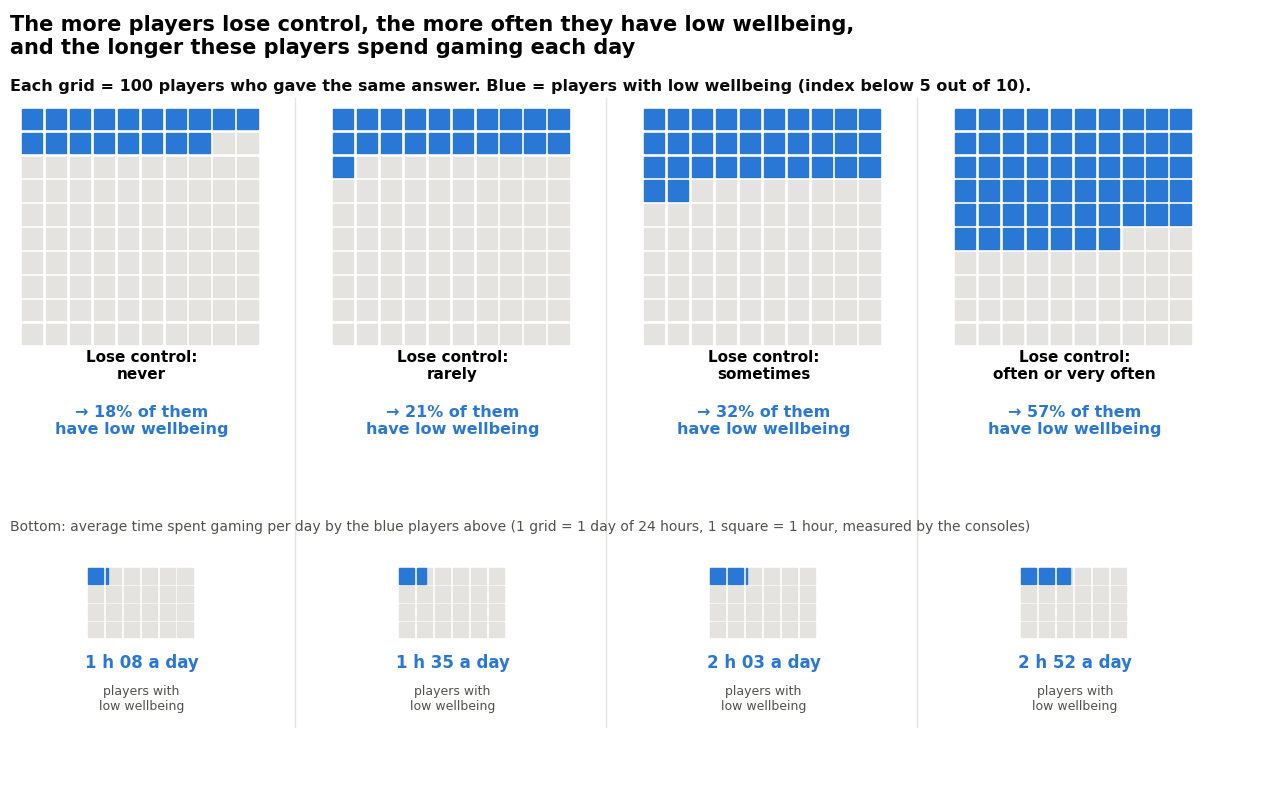

In [11]:
BLUE, EMPTY, INK, MUTED = "#2a78d6", "#e4e3df", "#0b0b0b", "#52514e"

def as_hours(minutes):
    minutes = int(round(minutes))
    return f"{minutes // 60} h {minutes % 60:02d}"

fig, ax = plt.subplots(figsize=(13, 10))
ax.axis("off")
ax.set_aspect("equal")
ax.set_xlim(-0.5, 52)
ax.set_ylim(-19, 13.5)

ax.text(-0.5, 13.3, "The more players lose control, the more often they have low wellbeing,\n"
        "and the longer these players spend gaming each day", fontsize=15, fontweight="bold", va="top")
ax.text(-0.5, 10.6, "Each grid = 100 players who gave the same answer. "
        "Blue = players with low wellbeing (index below 5 out of 10).", fontsize=11.5, fontweight="bold",
        color=INK, va="top")

for k, row in results.iterrows():
    x0 = k * 13
    pct = int(round(row["pct_low_wellbeing"]))

    # Top: 10 x 10 waffle, one square = 1% of the group
    for i in range(100):
        r, c = divmod(i, 10)
        ax.add_patch(plt.Rectangle((x0 + c, 8.5 - r), 0.85, 0.85, color=BLUE if i < pct else EMPTY))
    ax.text(x0 + 5, -0.7, f"Lose control:\n{row['group']}", ha="center", va="top", fontsize=11, fontweight="bold")
    ax.text(x0 + 5, -3.0, f"→ {pct}% of them\nhave low wellbeing", ha="center", va="top",
            fontsize=11.5, fontweight="bold", color=BLUE)

    # Bottom: 4 x 6 grid = 24 hours, filled with the average daily playtime
    hours = row["minutes_per_day_low"] / 60
    for h in range(24):
        r, c = divmod(h, 6)
        x, y = x0 + 2.75 + c * 0.75, -10.5 - r * 0.75
        ax.add_patch(plt.Rectangle((x, y), 0.65, 0.65, color=EMPTY))
        fill = min(max(hours - h, 0), 1)                # partially fill the last hour
        if fill > 0:
            ax.add_patch(plt.Rectangle((x, y), 0.65 * fill, 0.65, color=BLUE))
    ax.text(x0 + 5, -13.4, as_hours(row["minutes_per_day_low"]) + " a day", ha="center", va="top",
            fontsize=12, fontweight="bold", color=BLUE)
    ax.text(x0 + 5, -14.7, "players with\nlow wellbeing", ha="center", va="top", fontsize=9, color=MUTED)

ax.text(-0.5, -7.8, "Bottom: average time spent gaming per day by the blue players above "
        "(1 grid = 1 day of 24 hours, 1 square = 1 hour, measured by the consoles)", fontsize=10, color=MUTED, va="top")
for k in range(1, 4):                                    # light separators between the columns
    ax.plot([k * 13 - 1.6, k * 13 - 1.6], [-16.5, 9.8], color=EMPTY, linewidth=1)

plt.tight_layout()
plt.show()

**How to read it:** among players who **never** lose control, about 18% have low wellbeing;
among those who lose control **often or very often**, 57% do: more than one in two (vs one in four overall).
At the bottom, the low-wellbeing players' gaming day gets longer as loss of control increases
(from about 1 hour to almost 3 hours a day).
This is an **association**, not a cause: feeling low can also make it harder to stop playing.

## Step 7  Interactive chart (Bokeh)

Same chart. Hover over any square to see the group, the percentage and the real number of players.

In [12]:
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource, HoverTool, Label
from bokeh.plotting import figure

output_notebook()

top = {"x": [], "y": [], "color": [], "group": [], "pct": [], "low": [], "players": []}
bottom = {"x": [], "y": [], "color": [], "group": [], "time": [], "n": []}
for k, row in results.iterrows():
    x0 = k * 13
    pct = int(round(row["pct_low_wellbeing"]))
    for i in range(100):
        r, c = divmod(i, 10)
        top["x"].append(x0 + c + 0.42); top["y"].append(8.5 - r + 0.42)
        top["color"].append(BLUE if i < pct else EMPTY)
        top["group"].append(row["group"]); top["pct"].append(pct)
        top["low"].append(int(row["low_wellbeing_players"])); top["players"].append(int(row["players"]))
    hours = row["minutes_per_day_low"] / 60
    for h in range(24):
        r, c = divmod(h, 6)
        bottom["x"].append(x0 + 2.75 + c * 0.75 + 0.33); bottom["y"].append(-10.5 - r * 0.75 + 0.33)
        bottom["color"].append(BLUE if hours - h >= 0.5 else EMPTY)     # square coloured if at least half filled
        bottom["group"].append(row["group"]); bottom["time"].append(as_hours(row["minutes_per_day_low"]))
        bottom["n"].append(int(row["low_with_console_data"]))

p = figure(width=950, height=650, x_range=(-0.5, 52), y_range=(-17, 12), match_aspect=True,
           toolbar_location=None,
           title="The more players lose control, the more often they have low wellbeing, and the longer they play")
top_glyph = p.rect("x", "y", width=0.85, height=0.85, color="color", source=ColumnDataSource(top))
bottom_glyph = p.rect("x", "y", width=0.65, height=0.65, color="color", source=ColumnDataSource(bottom))
p.add_tools(HoverTool(renderers=[top_glyph], tooltips=[
    ("Lose control", "@group"), ("Low wellbeing", "@pct% of them (@low of @players players)")]))
p.add_tools(HoverTool(renderers=[bottom_glyph], tooltips=[
    ("Lose control", "@group"), ("Average gaming time", "@time a day (@n players with low wellbeing)")]))

for k, row in results.iterrows():
    x0 = k * 13
    pct = int(round(row["pct_low_wellbeing"]))
    p.add_layout(Label(x=x0 + 5, y=-1.4, text=f"Lose control: {row['group']}", text_align="center",
                       text_font_size="12px", text_font_style="bold", text_color=INK))
    p.add_layout(Label(x=x0 + 5, y=-3.2, text=f"→ {pct}% of them have low wellbeing", text_align="center",
                       text_font_size="12px", text_font_style="bold", text_color=BLUE))
    p.add_layout(Label(x=x0 + 5, y=-14.6, text=as_hours(row["minutes_per_day_low"]) + " a day",
                       text_align="center", text_font_size="13px", text_font_style="bold", text_color=BLUE))
p.add_layout(Label(x=-0.5, y=10.0, text="Each grid = 100 players who gave the same answer. "
                   "Blue = players with low wellbeing (index below 5 out of 10).",
                   text_font_size="13px", text_font_style="bold", text_color=INK))
p.add_layout(Label(x=-0.5, y=-7.6, text="Average gaming time per day of the blue players above (1 square = 1 hour)",
                   text_font_size="11px", text_color=MUTED))

p.axis.visible = False
p.grid.visible = False
p.outline_line_color = None
show(p)

Loading BokehJS ...

## Checks and limits

- **Accessibility:** every grid carries its result in words ("→ 57% of them have low wellbeing", "2 h 52 a day"),
  so the chart can be read without relying on colour.
- **Reading direction:** the % is computed *inside* each loss-of-control group, not among low-wellbeing players.
- **Wellbeing index:** combines validated questionnaires, but the combination itself is home-made;
  the same pattern appears with the validated depression scale alone.
- **Playtime** is measured by the consoles (Xbox, Nintendo, Steam); PlayStation and mobile play are missing.
- **Association, not cause.**